In [1]:
!pip install -q scikit-learn pandas numpy matplotlib seaborn joblib

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    root_mean_squared_error
)

from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor
)

In [3]:
DATA_PATH = "/kaggle/input/datasets/kakulthisside/skin-health-dataset/Skin_Health_Dataset_5000.csv"

df = pd.read_csv(DATA_PATH)

In [4]:
print("Shape :", df.shape)

df.head()

Shape : (5000, 16)


,Age,Gender,Hydration_Level,Oil_Level,Sensitivity,Humidity,Temperature,Skin_Type,Sleep_Hours,Water_Intake_L,Exercise,Stress_Level,Diet,Smoking,Alcohol,Skin_Health_Score
0,58,Male,Low,Low,High,65.6,35.8,Dry,4,2.8,NaN,Low,Healthy,No,Never,44
1,59,Female,High,High,Low,73.3,32.0,Oily,6,1.8,Light,High,Healthy,No,Never,41
2,56,Female,High,Medium,Medium,57.2,37.5,Combination,7,1.2,Light,Medium,Junk,No,Never,42
3,20,Male,Low,Medium,Low,77.0,25.6,Combination,7,2.9,Light,Medium,Healthy,No,Frequently,62
4,22,Male,Medium,Medium,Low,39.7,27.2,Normal,6,4.0,Moderate,Medium,Mixed,Yes,Occasionally,48


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                5000 non-null   int64  
 1   Gender             5000 non-null   object 
 2   Hydration_Level    5000 non-null   object 
 3   Oil_Level          5000 non-null   object 
 4   Sensitivity        5000 non-null   object 
 5   Humidity           5000 non-null   float64
 6   Temperature        5000 non-null   float64
 7   Skin_Type          5000 non-null   object 
 8   Sleep_Hours        5000 non-null   int64  
 9   Water_Intake_L     5000 non-null   float64
 10  Exercise           4242 non-null   object 
 11  Stress_Level       5000 non-null   object 
 12  Diet               5000 non-null   object 
 13  Smoking            5000 non-null   object 
 14  Alcohol            5000 non-null   object 
 15  Skin_Health_Score  5000 non-null   int64  
dtypes: float64(3), int64(3),

In [6]:
df.isnull().sum()

Age                    0
Gender                 0
Hydration_Level        0
Oil_Level              0
Sensitivity            0
Humidity               0
Temperature            0
Skin_Type              0
Sleep_Hours            0
Water_Intake_L         0
Exercise             758
Stress_Level           0
Diet                   0
Smoking                0
Alcohol                0
Skin_Health_Score      0
dtype: int64

In [7]:
df.describe(include="all")

,Age,Gender,Hydration_Level,Oil_Level,Sensitivity,Humidity,Temperature,Skin_Type,Sleep_Hours,Water_Intake_L,Exercise,Stress_Level,Diet,Smoking,Alcohol,Skin_Health_Score
count,5000.000000,5000,5000,5000,5000,5000.000000,5000.00000,5000,5000.000000,5000.000000,4242,5000,5000,5000,5000,5000.000000
unique,NaN,2,3,3,3,NaN,NaN,5,NaN,NaN,3,3,4,2,3,NaN
top,NaN,Male,Medium,Medium,Low,NaN,NaN,Normal,NaN,NaN,Moderate,Medium,Balanced,No,Never,NaN
freq,NaN,2516,2573,2690,2297,NaN,NaN,1230,NaN,NaN,1481,2047,1777,4136,2973,NaN
mean,39.199800,NaN,NaN,NaN,NaN,55.659960,27.84984,NaN,6.553400,2.506620,NaN,NaN,NaN,NaN,NaN,57.630800
std,12.449164,NaN,NaN,NaN,NaN,17.291564,5.77240,NaN,1.703798,0.876182,NaN,NaN,NaN,NaN,NaN,20.424513
min,18.000000,NaN,NaN,NaN,NaN,25.000000,18.00000,NaN,4.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000
25%,29.000000,NaN,NaN,NaN,NaN,40.800000,22.80000,NaN,5.000000,1.800000,NaN,NaN,NaN,NaN,NaN,44.000000
50%,39.000000,NaN,NaN,NaN,NaN,56.100000,27.65000,NaN,7.000000,2.500000,NaN,NaN,NaN,NaN,NaN,59.000000
75%,50.000000,NaN,NaN,NaN,NaN,70.600000,32.80000,NaN,8.000000,3.300000,NaN,NaN,NaN,NaN,NaN,72.000000


In [8]:
df.describe(include="all")

,Age,Gender,Hydration_Level,Oil_Level,Sensitivity,Humidity,Temperature,Skin_Type,Sleep_Hours,Water_Intake_L,Exercise,Stress_Level,Diet,Smoking,Alcohol,Skin_Health_Score
count,5000.000000,5000,5000,5000,5000,5000.000000,5000.00000,5000,5000.000000,5000.000000,4242,5000,5000,5000,5000,5000.000000
unique,NaN,2,3,3,3,NaN,NaN,5,NaN,NaN,3,3,4,2,3,NaN
top,NaN,Male,Medium,Medium,Low,NaN,NaN,Normal,NaN,NaN,Moderate,Medium,Balanced,No,Never,NaN
freq,NaN,2516,2573,2690,2297,NaN,NaN,1230,NaN,NaN,1481,2047,1777,4136,2973,NaN
mean,39.199800,NaN,NaN,NaN,NaN,55.659960,27.84984,NaN,6.553400,2.506620,NaN,NaN,NaN,NaN,NaN,57.630800
std,12.449164,NaN,NaN,NaN,NaN,17.291564,5.77240,NaN,1.703798,0.876182,NaN,NaN,NaN,NaN,NaN,20.424513
min,18.000000,NaN,NaN,NaN,NaN,25.000000,18.00000,NaN,4.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000
25%,29.000000,NaN,NaN,NaN,NaN,40.800000,22.80000,NaN,5.000000,1.800000,NaN,NaN,NaN,NaN,NaN,44.000000
50%,39.000000,NaN,NaN,NaN,NaN,56.100000,27.65000,NaN,7.000000,2.500000,NaN,NaN,NaN,NaN,NaN,59.000000
75%,50.000000,NaN,NaN,NaN,NaN,70.600000,32.80000,NaN,8.000000,3.300000,NaN,NaN,NaN,NaN,NaN,72.000000


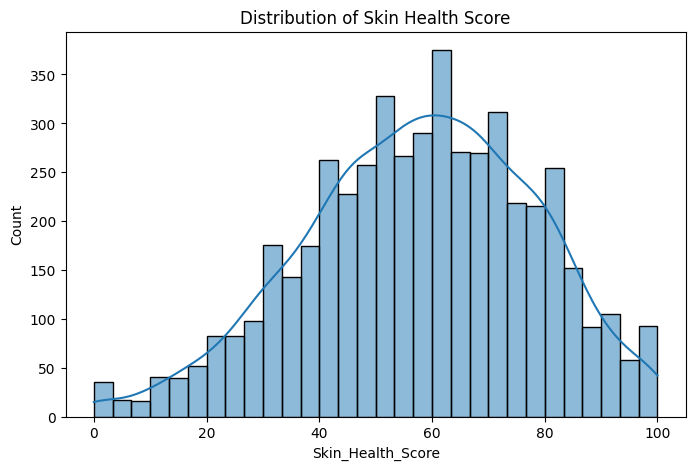

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(df["Skin_Health_Score"], bins=30, kde=True)

plt.title("Distribution of Skin Health Score")

plt.show()

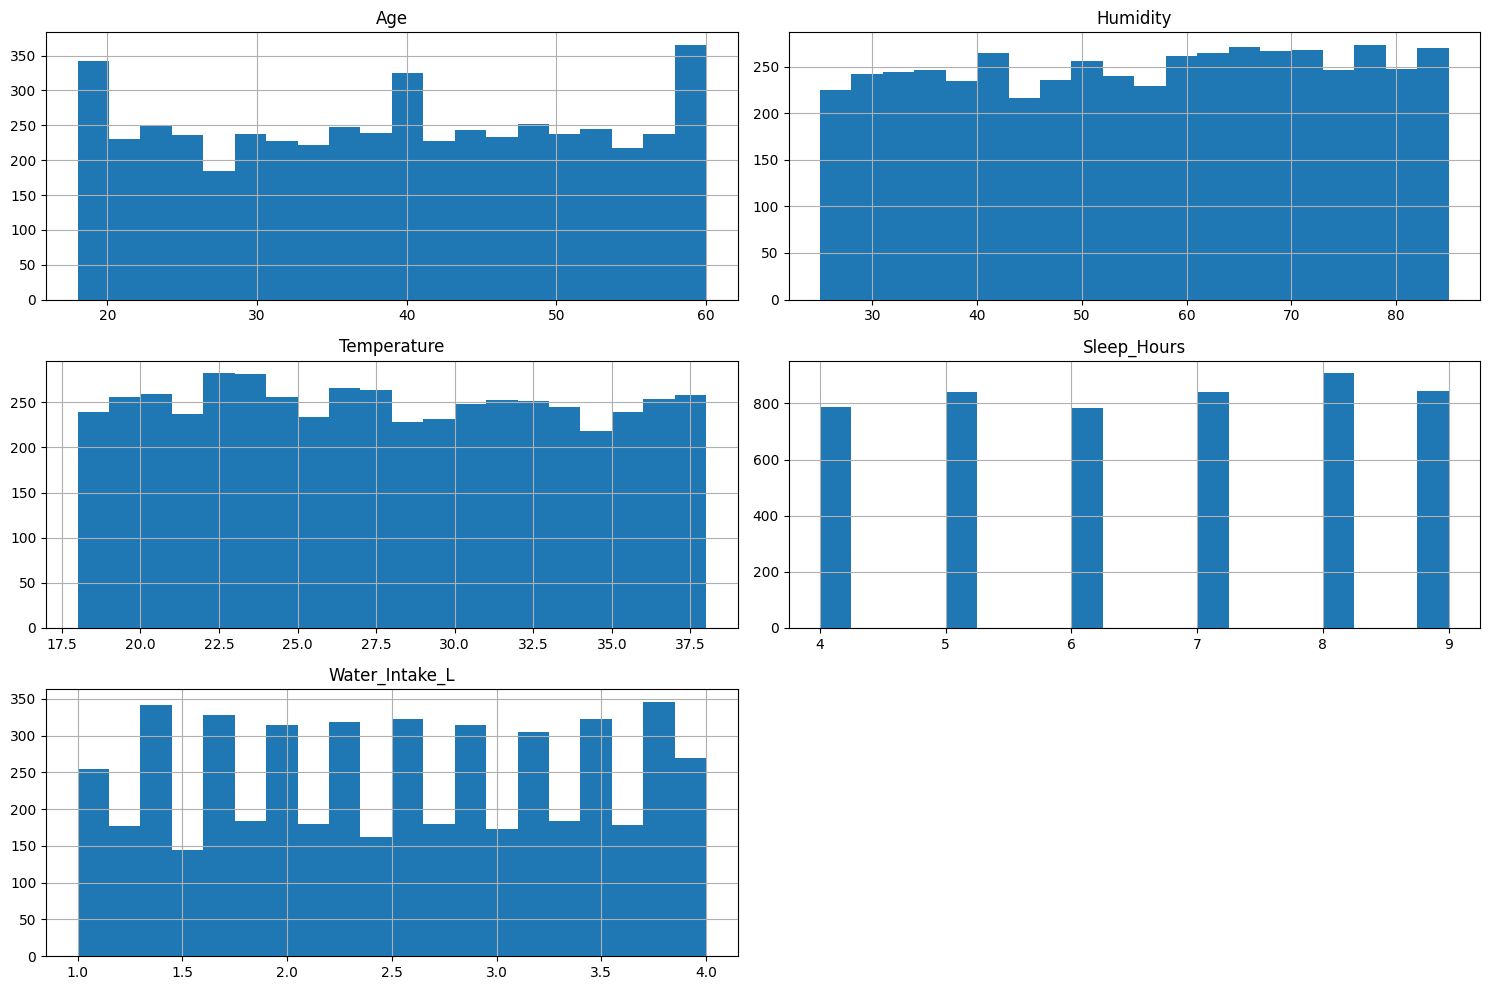

In [10]:
numerical_columns = [
    "Age",
    "Hydration_Level",
    "Oil_Level",
    "Humidity",
    "Temperature",
    "Sleep_Hours",
    "Water_Intake_L"
]

df[numerical_columns].hist(
    figsize=(15,10),
    bins=20
)

plt.tight_layout()

plt.show()

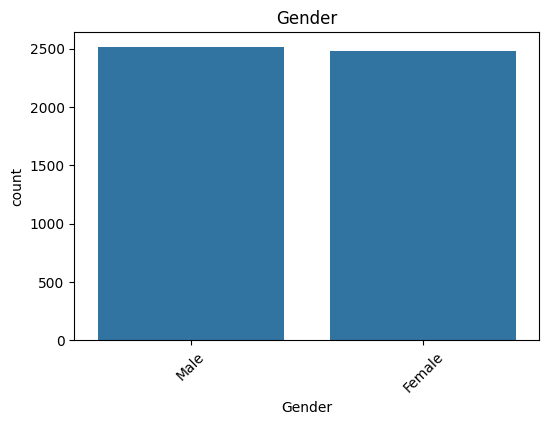

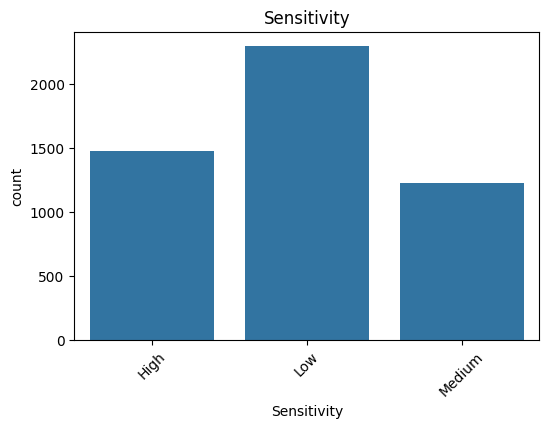

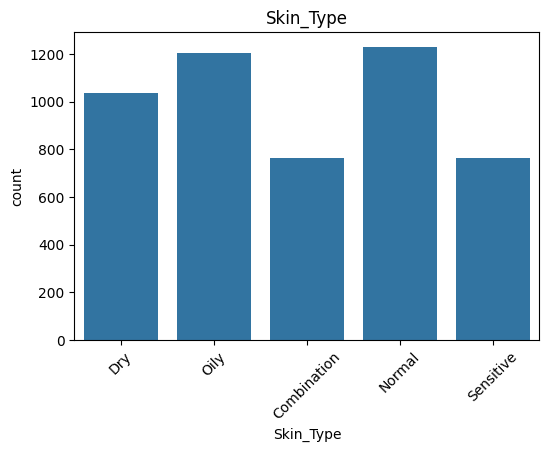

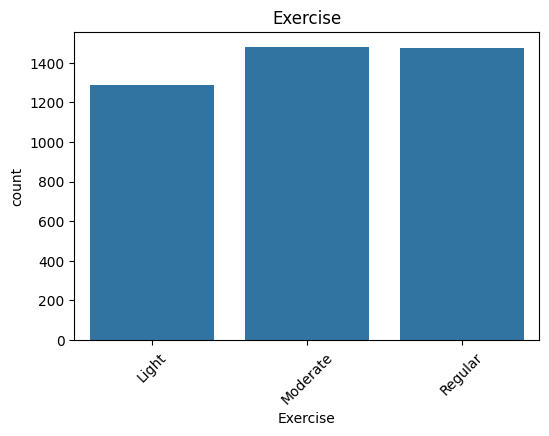

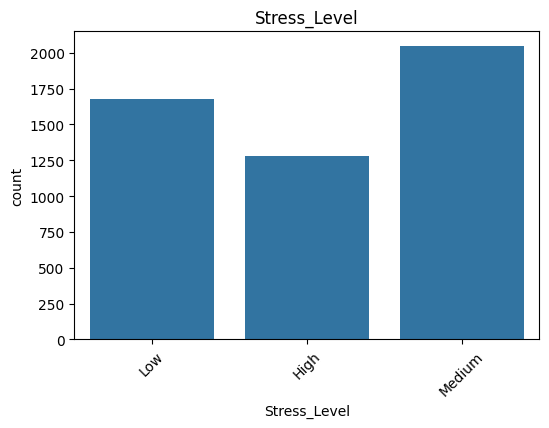

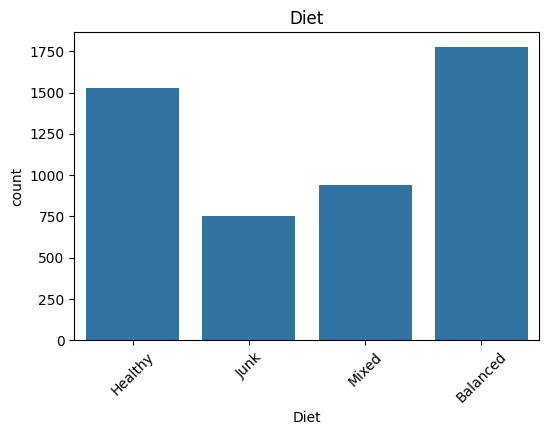

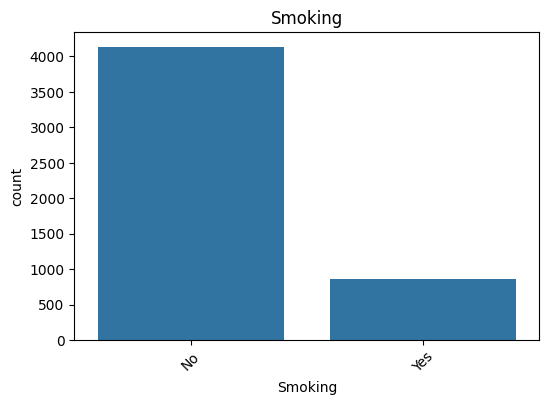

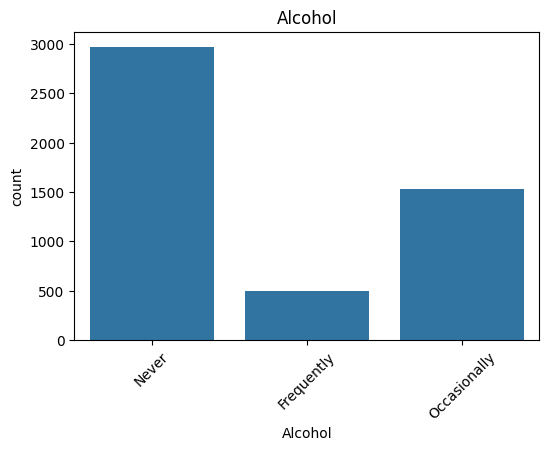

In [11]:
categorical_columns = [
    "Gender",
    "Sensitivity",
    "Skin_Type",
    "Exercise",
    "Stress_Level",
    "Diet",
    "Smoking",
    "Alcohol"
]

for col in categorical_columns:

    plt.figure(figsize=(6,4))

    sns.countplot(
        data=df,
        x=col
    )

    plt.xticks(rotation=45)

    plt.title(col)

    plt.show()

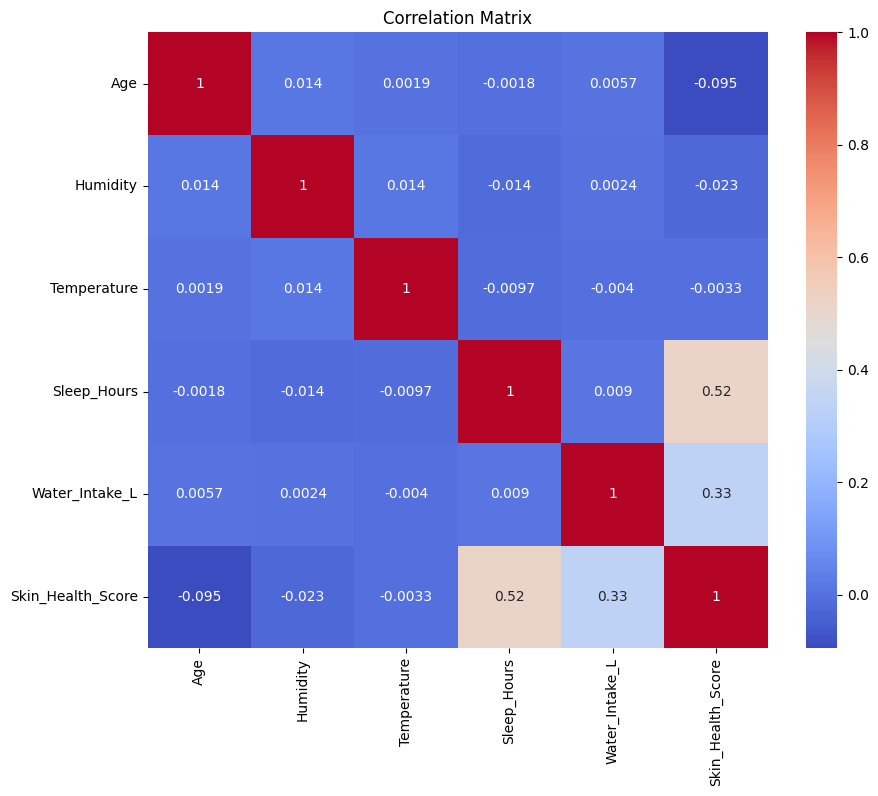

In [12]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

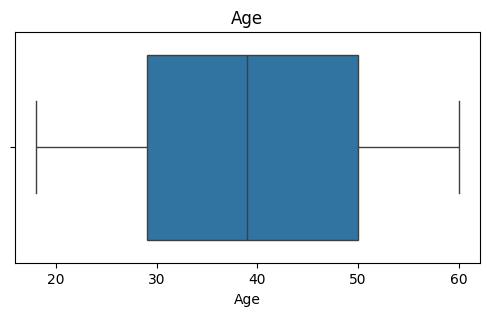

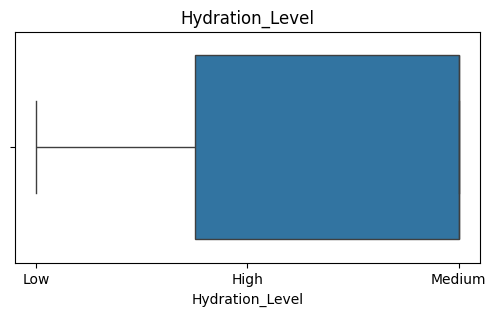

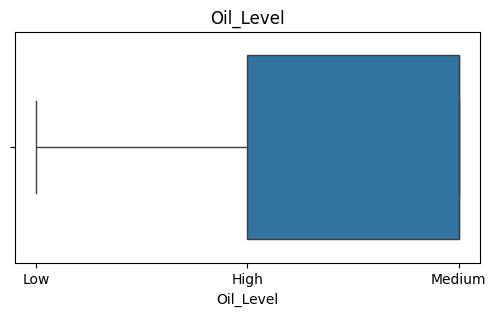

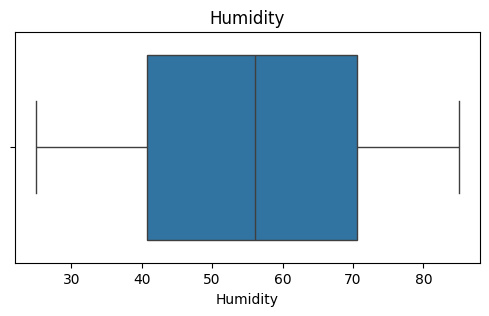

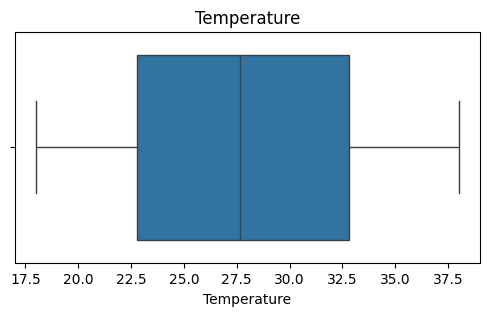

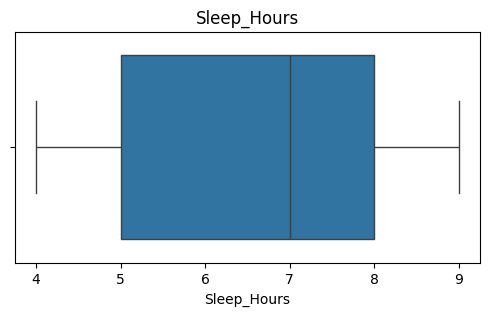

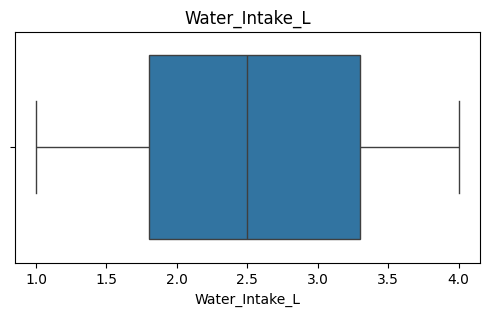

In [13]:
for col in numerical_columns:

    plt.figure(figsize=(6,3))

    sns.boxplot(
        x=df[col]
    )

    plt.title(col)

    plt.show()

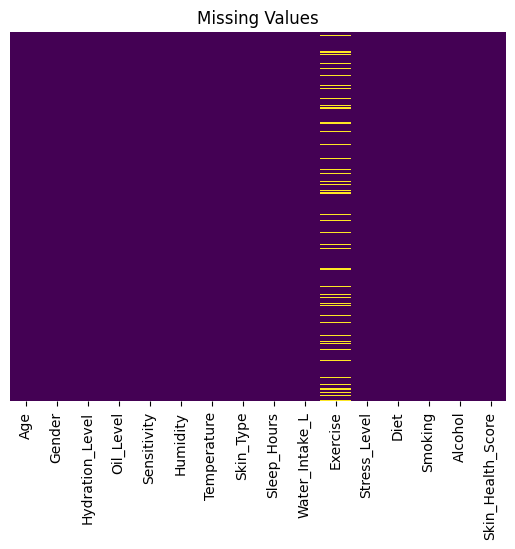

In [14]:
sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False,
    cmap="viridis"
)

plt.title("Missing Values")

plt.show()

In [15]:
X = df.drop("Skin_Health_Score", axis=1)
y = df["Skin_Health_Score"]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (5000, 15)
Target Shape : (5000,)


In [16]:
numerical_features = [
    "Age",
    "Humidity",
    "Temperature",
    "Sleep_Hours",
    "Water_Intake_L"
]

categorical_features = [
    "Gender",
    "Hydration_Level",
    "Oil_Level",
    "Sensitivity",
    "Skin_Type",
    "Exercise",
    "Stress_Level",
    "Diet",
    "Smoking",
    "Alcohol"
]
print("Numerical Features :", numerical_features)
print("Categorical Features :", categorical_features)

Numerical Features : ['Age', 'Humidity', 'Temperature', 'Sleep_Hours', 'Water_Intake_L']
Categorical Features : ['Gender', 'Hydration_Level', 'Oil_Level', 'Sensitivity', 'Skin_Type', 'Exercise', 'Stress_Level', 'Diet', 'Smoking', 'Alcohol']


In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Numerical columns
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical columns
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (4000, 15)
Testing Shape : (1000, 15)


In [19]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(X_train_processed.shape)
print(X_test_processed.shape)

(4000, 36)
(1000, 36)


In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor
)

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    root_mean_squared_error
)

In [21]:
models = {

    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

}

In [22]:
results = []

trained_models = {}

for name, model in models.items():

    print("=" * 60)
    print(f"Training {name}...")

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    r2 = r2_score(y_test, y_pred)

    mae = mean_absolute_error(y_test, y_pred)

    rmse = root_mean_squared_error(y_test, y_pred)

    results.append([name, r2, mae, rmse])

    trained_models[name] = pipeline

    print(f"R² Score : {r2:.4f}")
    print(f"MAE      : {mae:.4f}")
    print(f"RMSE     : {rmse:.4f}")

Training Linear Regression...
R² Score : 0.8952
MAE      : 5.2474
RMSE     : 6.5939
Training Decision Tree...
R² Score : 0.6950
MAE      : 8.8910
RMSE     : 11.2505
Training Random Forest...
R² Score : 0.8685
MAE      : 5.7923
RMSE     : 7.3869
Training Gradient Boosting...
R² Score : 0.9245
MAE      : 4.4287
RMSE     : 5.5986
Training Extra Trees...
R² Score : 0.8503
MAE      : 6.1771
RMSE     : 7.8832


In [23]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "R2 Score",
        "MAE",
        "RMSE"
    ]
)

results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
)

results_df

,Model,R2 Score,MAE,RMSE
3,Gradient Boosting,0.924479,4.428680,5.598641
0,Linear Regression,0.895240,5.247425,6.593935
2,Random Forest,0.868528,5.792325,7.386932
4,Extra Trees,0.850271,6.177135,7.883161
1,Decision Tree,0.695037,8.891000,11.250467


In [24]:
best_model_name = results_df.iloc[0]["Model"]

print("🏆 Best Model :", best_model_name)

best_pipeline = trained_models[best_model_name]

🏆 Best Model : Gradient Boosting


In [25]:
import joblib

joblib.dump(
    best_pipeline,
    "skin_health_model.joblib"
)

print("✅ Best model saved successfully.")

✅ Best model saved successfully.
